In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

In [2]:
# Load Fashion MNIST data
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

# Normalize pixel values to 0-1
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Add channel dimension for CNN
X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print("CNN training shape:", X_train.shape)
print("CNN test shape:", X_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training shape: (60000, 28, 28)
Test shape: (10000, 28, 28)
CNN training shape: (60000, 28, 28, 1)
CNN test shape: (10000, 28, 28, 1)


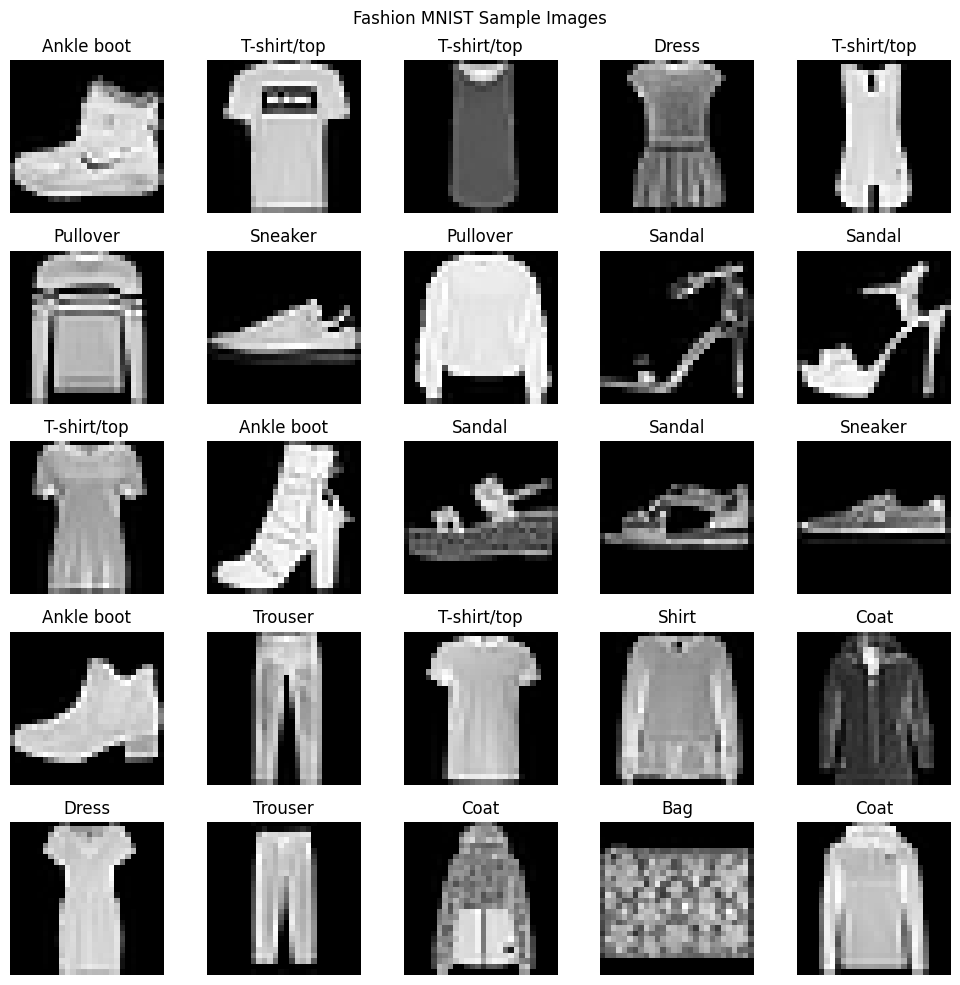

In [3]:
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

plt.figure(figsize=(10, 10))

for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(X_train[i].squeeze(), cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.suptitle("Fashion MNIST Sample Images")
plt.tight_layout()
plt.show()

In [4]:
def plot_training_curves(history, title):
    plt.figure(figsize=(12, 5))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="Training Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(title + " Accuracy")
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title + " Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()


def evaluate_model(model, X_test, y_test, model_name):
    y_pred_prob = model.predict(X_test)
    y_pred = np.argmax(y_pred_prob, axis=1)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted")
    recall = recall_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")

    print(f"\n{model_name} Test Evaluation")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")

    return accuracy, precision, recall, f1

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 27s 15ms/step - accuracy: 0.8540 - loss: 0.4127 - val_accuracy: 0.8832 - val_loss: 0.3261
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.8976 - loss: 0.2818 - val_accuracy: 0.8925 - val_loss: 0.2986
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.9126 - loss: 0.2405 - val_accuracy: 0.9022 - val_loss: 0.2795
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.9231 - loss: 0.2100 - val_accuracy: 0.9053 - val_loss: 0.2725
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.9329 - loss: 0.1836 - val_accuracy: 0.9073 - val_loss: 0.2720


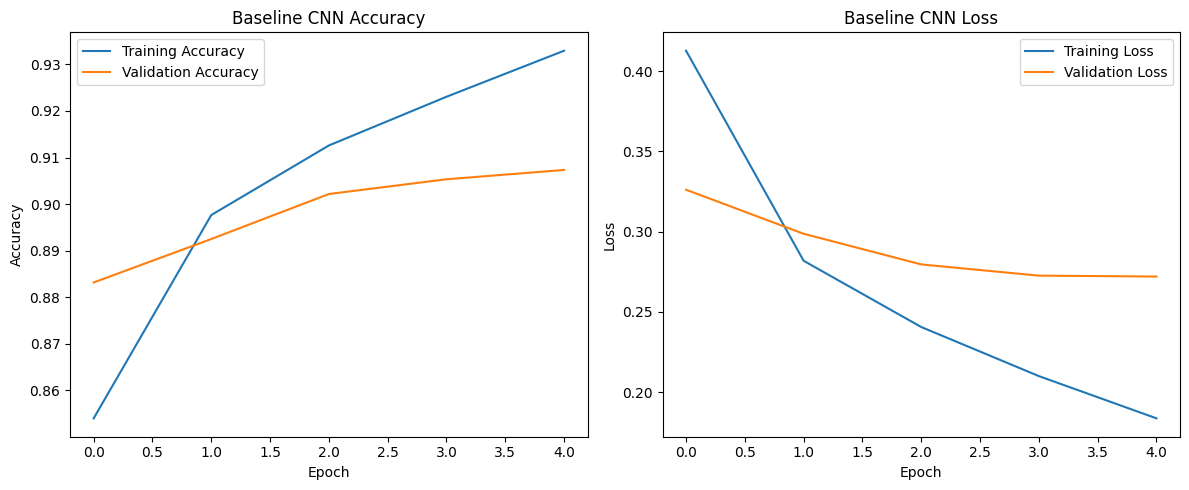

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

Baseline CNN Test Evaluation
Accuracy:  0.9022
Precision: 0.9035
Recall:    0.9022
F1 Score:  0.8998


In [5]:
tf.random.set_seed(42)

baseline_model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

baseline_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

baseline_history = baseline_model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

plot_training_curves(baseline_history, "Baseline CNN")

baseline_results = evaluate_model(
    baseline_model,
    X_test,
    y_test,
    "Baseline CNN"
)

# Baseline CNN

The baseline CNN used one convolutional layer, max pooling, and one dense hidden layer. This model established a reference point for later experiments. 

It achieved strong overall classification performance on the Fashion MNIST dataset, reaching a test accuracy of approximately 90.2%. Both training and validation accuracy steadily improved across epochs, while training and validation loss decreased consistently.

However, the training curves began improving faster than the validation curves during later epochs. Validation loss also started to flatten while training loss continued decreasing, suggesting the beginning of mild overfitting.

Overall, the baseline CNN provided a strong reference point for later experiments involving regularization, larger model capacity, and systematic hyperparameter tuning.

Epoch 1/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 34s 20ms/step - accuracy: 0.8211 - loss: 0.5127 - val_accuracy: 0.8728 - val_loss: 0.3512
Epoch 2/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 26s 16ms/step - accuracy: 0.8796 - loss: 0.3424 - val_accuracy: 0.8858 - val_loss: 0.3077
Epoch 3/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.8934 - loss: 0.3000 - val_accuracy: 0.8992 - val_loss: 0.2797
Epoch 4/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.9020 - loss: 0.2715 - val_accuracy: 0.8992 - val_loss: 0.2769
Epoch 5/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.9083 - loss: 0.2514 - val_accuracy: 0.9008 - val_loss: 0.2745
Epoch 6/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.9128 - loss: 0.2339 - val_accuracy: 0.9083 - val_loss: 0.2631
Epoch 7/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.9189 - loss: 0.2186 - val_accuracy: 0.9068 - val_loss: 0.2715
Epoch 8/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 0.9237 - loss: 0

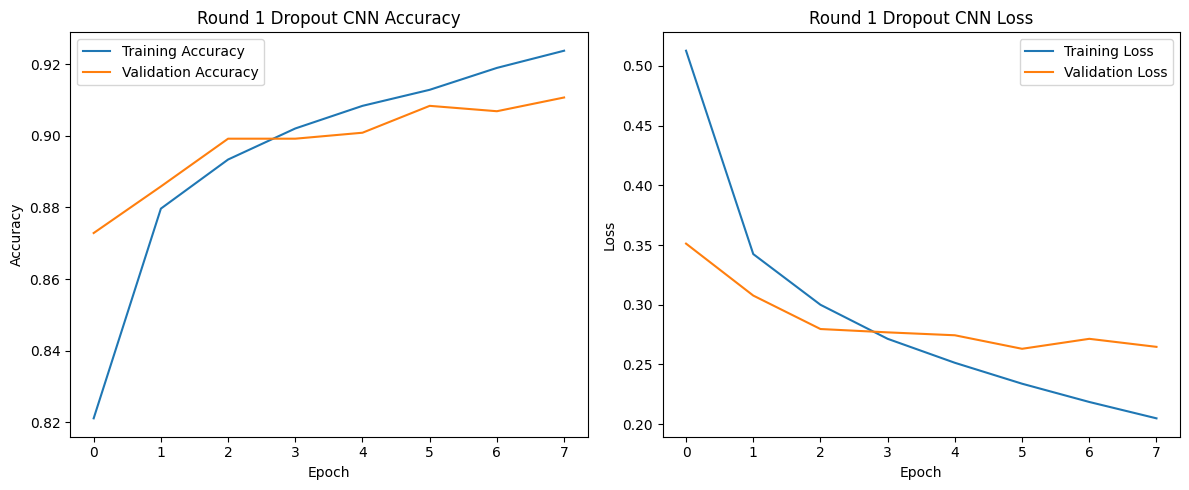

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Round 1 Dropout CNN Test Evaluation
Accuracy:  0.9085
Precision: 0.9083
Recall:    0.9085
F1 Score:  0.9076


In [6]:
tf.random.set_seed(42)

dropout_model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(10, activation="softmax")
])

dropout_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

dropout_history = dropout_model.fit(
    X_train,
    y_train,
    epochs=8,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

plot_training_curves(dropout_history, "Round 1 Dropout CNN")

dropout_results = evaluate_model(
    dropout_model,
    X_test,
    y_test,
    "Round 1 Dropout CNN"
)

Round 1 added dropout regularization after the dense hidden layer to reduce overfitting and improve model generalization.

Compared to the baseline CNN, the gap between training and validation accuracy became smaller, suggesting that the model relied less on memorizing training examples. Validation loss also remained more stable throughout training, while validation accuracy improved slightly.

The dropout model achieved a test accuracy of approximately 90.9%, improving slightly over the baseline CNN. Overall, dropout regularization helped improve generalization performance while reducing overfitting behavior.

# Round 2 : Larger CNN Architecture


Epoch 1/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.8539 - loss: 0.4044 - val_accuracy: 0.8903 - val_loss: 0.3006
Epoch 2/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 41s 24ms/step - accuracy: 0.9030 - loss: 0.2631 - val_accuracy: 0.9035 - val_loss: 0.2658
Epoch 3/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 73s 19ms/step - accuracy: 0.9201 - loss: 0.2168 - val_accuracy: 0.9112 - val_loss: 0.2500
Epoch 4/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 33s 19ms/step - accuracy: 0.9340 - loss: 0.1799 - val_accuracy: 0.9142 - val_loss: 0.2491
Epoch 5/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 34s 20ms/step - accuracy: 0.9462 - loss: 0.1483 - val_accuracy: 0.9118 - val_loss: 0.2672
Epoch 6/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 35s 21ms/step - accuracy: 0.9574 - loss: 0.1188 - val_accuracy: 0.9140 - val_loss: 0.2896
Epoch 7/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 34s 20ms/step - accuracy: 0.9668 - loss: 0.0937 - val_accuracy: 0.9038 - val_loss: 0.3702
Epoch 8/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 34s 20ms/step - accuracy: 0.9720 - loss: 0

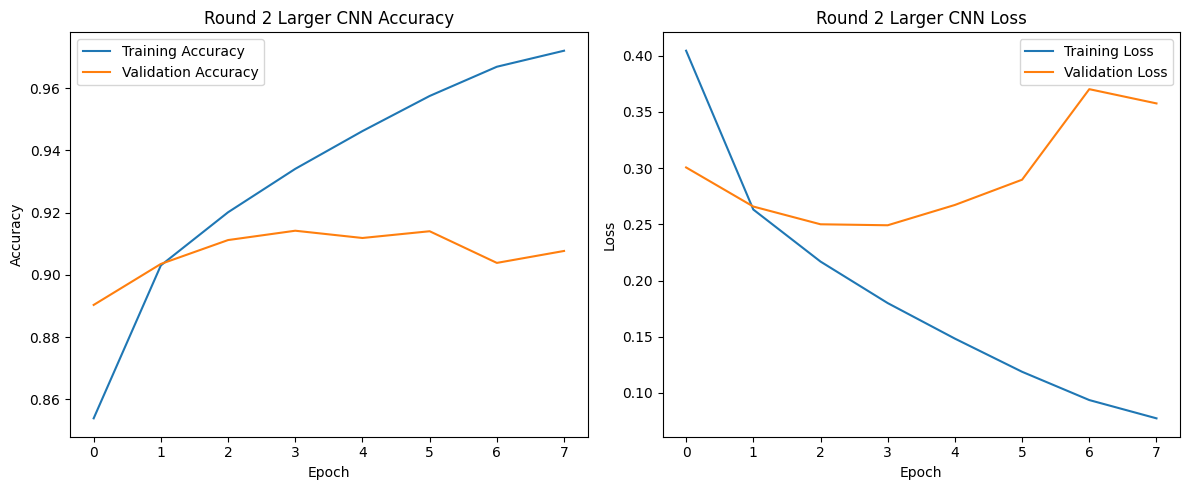

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step

Round 2 Larger CNN Test Evaluation
Accuracy:  0.9052
Precision: 0.9070
Recall:    0.9052
F1 Score:  0.9039


In [7]:
tf.random.set_seed(42)

larger_model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax")
])

larger_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

larger_history = larger_model.fit(
    X_train,
    y_train,
    epochs=8,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

plot_training_curves(larger_history, "Round 2 Larger CNN")

larger_results = evaluate_model(
    larger_model,
    X_test,
    y_test,
    "Round 2 Larger CNN"
)

Round 2 increased the CNN model capacity by adding an additional convolutional layer and a larger dense hidden layer. The goal was to test whether a deeper architecture would improve feature extraction and classification performance.

Although the larger CNN achieved much higher training accuracy, validation accuracy improved only slightly and eventually plateaued. Validation loss also began increasing during later epochs while training loss continued decreasing rapidly, indicating clear overfitting behavior.

Compared to the previous dropout model, the larger CNN produced weaker generalization performance despite its increased complexity. The test accuracy remained similar overall, suggesting diminishing returns from simply increasing CNN depth and model capacity.

This experiment demonstrated that larger architectures can memorize training data more easily without necessarily improving performance on unseen test images.

# Round 3 : Batch Normalization CNN


Epoch 1/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 53s 30ms/step - accuracy: 0.8542 - loss: 0.4079 - val_accuracy: 0.8848 - val_loss: 0.3137
Epoch 2/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 62s 37ms/step - accuracy: 0.8999 - loss: 0.2741 - val_accuracy: 0.9013 - val_loss: 0.2760
Epoch 3/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 90s 53ms/step - accuracy: 0.9149 - loss: 0.2325 - val_accuracy: 0.9052 - val_loss: 0.2621
Epoch 4/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 145s 55ms/step - accuracy: 0.9261 - loss: 0.2021 - val_accuracy: 0.9133 - val_loss: 0.2552
Epoch 5/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 137s 52ms/step - accuracy: 0.9358 - loss: 0.1767 - val_accuracy: 0.9132 - val_loss: 0.2613
Epoch 6/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 87s 52ms/step - accuracy: 0.9443 - loss: 0.1536 - val_accuracy: 0.9070 - val_loss: 0.2770
Epoch 7/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 86s 51ms/step - accuracy: 0.9519 - loss: 0.1338 - val_accuracy: 0.9148 - val_loss: 0.2757
Epoch 8/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 78s 46ms/step - accuracy: 0.9586 - loss:

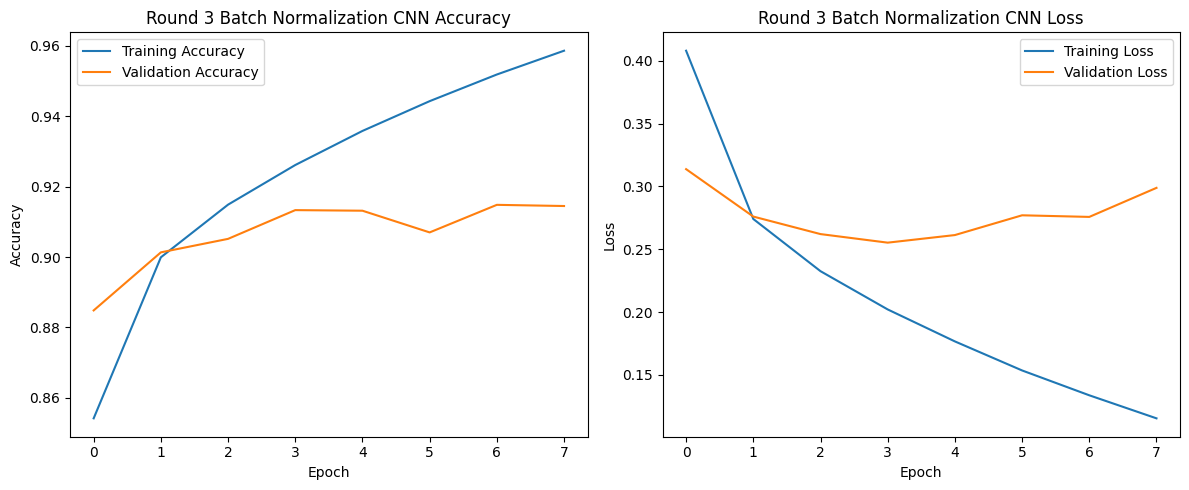

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step

Round 3 Batch Normalization CNN Test Evaluation
Accuracy:  0.9068
Precision: 0.9077
Recall:    0.9068
F1 Score:  0.9041


In [8]:
tf.random.set_seed(42)

batchnorm_model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(32, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax")
])

batchnorm_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

batchnorm_history = batchnorm_model.fit(
    X_train,
    y_train,
    epochs=8,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

plot_training_curves(batchnorm_history, "Round 3 Batch Normalization CNN")

batchnorm_results = evaluate_model(
    batchnorm_model,
    X_test,
    y_test,
    "Round 3 Batch Normalization CNN"
)

Round 3 introduced batch normalization layers after each convolutional layer to improve training stability and normalize intermediate feature distributions during learning.

Compared to the previous larger CNN model, the training curves became smoother and optimization behavior appeared more stable overall. However, validation accuracy improved only slightly, while validation loss still began increasing during later epochs.

Although batch normalization helped stabilize training, the model continued to show signs of overfitting as training accuracy kept increasing while validation performance plateaued. The test accuracy improved slightly compared to the larger CNN model, but remained below the earlier dropout experiment.

This experiment suggests that batch normalization improved optimization stability more effectively than overall generalization performance for this Fashion MNIST classification task.

# Round 4 : L2 Regularization + Dropout + EarlyStopping

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 106s 59ms/step - accuracy: 0.8201 - loss: 0.6143 - val_accuracy: 0.8682 - val_loss: 0.4384
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 101s 60ms/step - accuracy: 0.8735 - loss: 0.4476 - val_accuracy: 0.8957 - val_loss: 0.3716
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 110s 41ms/step - accuracy: 0.8860 - loss: 0.4056 - val_accuracy: 0.8953 - val_loss: 0.3824
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 77s 46ms/step - accuracy: 0.8944 - loss: 0.3840 - val_accuracy: 0.9045 - val_loss: 0.3475
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 65s 38ms/step - accuracy: 0.8998 - loss: 0.3682 - val_accuracy: 0.8988 - val_loss: 0.3652
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 69s 41ms/step - accuracy: 0.9039 - loss: 0.3598 - val_accuracy: 0.9007 - val_loss: 0.3515
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 73s 43ms/step - accuracy: 0.9076 - loss: 0.3517 - val_accuracy: 0.9130 - val_loss: 0.3351
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 79s 47ms/step - accuracy: 0.911

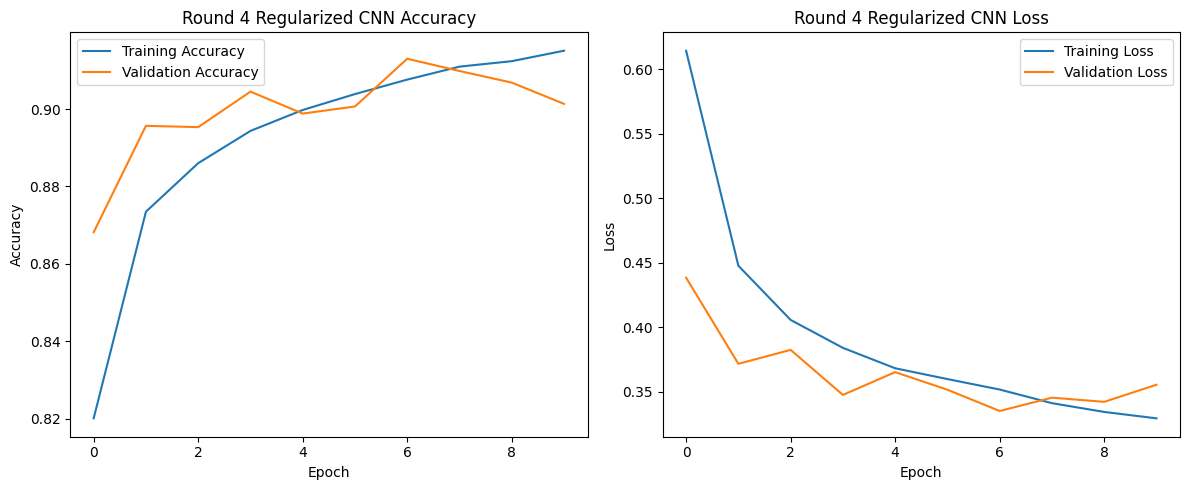

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step

Round 4 Regularized CNN Test Evaluation
Accuracy:  0.9069
Precision: 0.9075
Recall:    0.9069
F1 Score:  0.9055


In [9]:
tf.random.set_seed(42)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

regularized_model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(
        32,
        (3, 3),
        padding="same",
        kernel_regularizer=regularizers.l2(0.0005)
    ),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64,
        (3, 3),
        padding="same",
        kernel_regularizer=regularizers.l2(0.0005)
    ),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(
        128,
        activation="relu",
        kernel_regularizer=regularizers.l2(0.0005)
    ),
    layers.Dropout(0.3),

    layers.Dense(10, activation="softmax")
])

regularized_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

regularized_history = regularized_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

plot_training_curves(regularized_history, "Round 4 Regularized CNN")

regularized_results = evaluate_model(
    regularized_model,
    X_test,
    y_test,
    "Round 4 Regularized CNN"
)

Round 4 combined multiple regularization strategies, including L2 regularization, dropout, batch normalization, and early stopping. The goal was to reduce overfitting while maintaining strong classification performance.

Compared to the previous models, the training and validation curves remained much closer together throughout training, suggesting improved generalization behavior and more stable optimization. Validation loss also remained relatively stable across epochs without the sharp increases observed in earlier larger CNN experiments.

Although the final test accuracy was slightly lower than the earlier dropout-only model, the regularized CNN produced healthier training behavior overall with reduced overfitting and more consistent validation performance.

This experiment demonstrated that combining multiple regularization methods can improve model stability and generalization, even when the final accuracy gains are relatively modest.

In [10]:
results_df = pd.DataFrame({
    "Model": [
        "Baseline CNN",
        "Round 1: Dropout",
        "Round 2: Larger CNN",
        "Round 3: BatchNorm",
        "Round 4: L2 + Dropout + EarlyStopping"
    ],
    "Accuracy": [
        baseline_results[0],
        dropout_results[0],
        larger_results[0],
        batchnorm_results[0],
        regularized_results[0]
    ],
    "Precision": [
        baseline_results[1],
        dropout_results[1],
        larger_results[1],
        batchnorm_results[1],
        regularized_results[1]
    ],
    "Recall": [
        baseline_results[2],
        dropout_results[2],
        larger_results[2],
        batchnorm_results[2],
        regularized_results[2]
    ],
    "F1 Score": [
        baseline_results[3],
        dropout_results[3],
        larger_results[3],
        batchnorm_results[3],
        regularized_results[3]
    ]
})

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Baseline CNN,0.9022,0.903515,0.9022,0.899816
1,Round 1: Dropout,0.9085,0.908270,0.9085,0.907577
2,Round 2: Larger CNN,0.9052,0.906956,0.9052,0.903868
3,Round 3: BatchNorm,0.9068,0.907700,0.9068,0.904130
4,Round 4: L2 + Dropout + EarlyStopping,0.9069,0.907495,0.9069,0.905461


In [ ]:
%pip install optuna

In [ ]:
import optuna
from tensorflow.keras.optimizers import Adam

def objective(trial):

    tf.keras.backend.clear_session()

    filters_1 = trial.suggest_categorical("filters_1", [16, 32, 64])
    filters_2 = trial.suggest_categorical("filters_2", [32, 64, 128])
    dense_units = trial.suggest_categorical("dense_units", [64, 128, 256])
    dropout_rate = trial.suggest_float("dropout_rate", 0.2, 0.5)
    l2_rate = trial.suggest_float("l2_rate", 1e-5, 1e-3, log=True)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-3, log=True)
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])

    model = models.Sequential([
        layers.Input(shape=(28, 28, 1)),

        layers.Conv2D(
            filters_1,
            (3, 3),
            padding="same",
            kernel_regularizer=regularizers.l2(l2_rate)
        ),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(
            filters_2,
            (3, 3),
            padding="same",
            kernel_regularizer=regularizers.l2(l2_rate)
        ),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),

        layers.Dense(
            dense_units,
            activation="relu",
            kernel_regularizer=regularizers.l2(l2_rate)
        ),
        layers.Dropout(dropout_rate),

        layers.Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    )

    history = model.fit(
        X_train,
        y_train,
        epochs=15,
        batch_size=batch_size,
        validation_split=0.1,
        callbacks=[early_stop],
        verbose=0
    )

    best_val_acc = max(history.history["val_accuracy"])

    return best_val_acc


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=15)

print("Best trial:")
print(study.best_trial.params)
print("Best validation accuracy:", study.best_value)

c:\Users\young\tf-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-05-28 11:29:44,818] A new study created in memory with name: no-name-20aaf0d1-1560-4fd0-9707-f47713affae2


[I 2026-05-28 11:37:01,251] Trial 0 finished with value: 0.9108333587646484 and parameters: {'filters_1': 16, 'filters_2': 32, 'dense_units': 64, 'dropout_rate': 0.4844832747001854, 'l2_rate': 2.52499790380788e-05, 'learning_rate': 0.0009058903957162501, 'batch_size': 32}. Best is trial 0 with value: 0.9108333587646484.
